# Fandango Movie Ratings

#### Step 1 Exploring the Fandango datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fandango = pd.read_csv("../dataset/fandango_score_comparison.csv")
scrape = pd.read_csv("../dataset/fandango_scrape.csv")

In [2]:
print(fandango.shape)
print(scrape.shape)

(146, 22)
(510, 4)


In [3]:
fandango.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Fandango_Stars,Fandango_Ratingvalue,RT_norm,RT_user_norm,...,IMDB_norm,RT_norm_round,RT_user_norm_round,Metacritic_norm_round,Metacritic_user_norm_round,IMDB_norm_round,Metacritic_user_vote_count,IMDB_user_vote_count,Fandango_votes,Fandango_Difference
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,5.0,4.5,3.70,4.3,...,3.90,3.5,4.5,3.5,3.5,4.0,1330,271107,14846,0.5
1,Cinderella (2015),85,80,67,7.5,7.1,5.0,4.5,4.25,4.0,...,3.55,4.5,4.0,3.5,4.0,3.5,249,65709,12640,0.5
2,Ant-Man (2015),80,90,64,8.1,7.8,5.0,4.5,4.00,4.5,...,3.90,4.0,4.5,3.0,4.0,4.0,627,103660,12055,0.5
3,Do You Believe? (2015),18,84,22,4.7,5.4,5.0,4.5,0.90,4.2,...,2.70,1.0,4.0,1.0,2.5,2.5,31,3136,1793,0.5
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,3.5,3.0,0.70,1.4,...,2.55,0.5,1.5,1.5,1.5,2.5,88,19560,1021,0.5


In [4]:
scrape.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [5]:
fandango.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Fandango_Stars              146 non-null    float64
 7   Fandango_Ratingvalue        146 non-null    float64
 8   RT_norm                     146 non-null    float64
 9   RT_user_norm                146 non-null    float64
 10  Metacritic_norm             146 non-null    float64
 11  Metacritic_user_nom         146 non-null    float64
 12  IMDB_norm                   146 non-null    float64
 13  RT_norm_round               146 non

In [6]:
scrape.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    510 non-null    object 
 1   STARS   510 non-null    float64
 2   RATING  510 non-null    float64
 3   VOTES   510 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 16.1+ KB


#### Step 2 Compating Fandango stars to true ratings hidden in HTML

In [13]:
# Summary statistics
fandango['Fandango_Difference'].describe()

count    146.000000
mean       0.243836
std        0.152665
min        0.000000
25%        0.100000
50%        0.200000
75%        0.400000
max        0.500000
Name: Fandango_Difference, dtype: float64

In [14]:
fandango['Fandango_Difference'].mean()

np.float64(0.24383561643835613)

In [15]:
# Top 10 largest differences
fandango[
    [
        "FILM",
        "Fandango_Stars",
        "Fandango_Ratingvalue",
        "Fandango_Difference"        
    ]
].sort_values(
    by="Fandango_Difference", ascending=False
).head(10)

,FILM,Fandango_Stars,Fandango_Ratingvalue,Fandango_Difference
0,Avengers: Age of Ultron (2015),5.0,4.5,0.5
7,Top Five (2014),4.0,3.5,0.5
1,Cinderella (2015),5.0,4.5,0.5
12,Leviathan (2014),4.0,3.5,0.5
11,Black Sea (2015),4.0,3.5,0.5
9,Love & Mercy (2015),4.5,4.0,0.5
8,Shaun the Sheep Movie (2015),4.5,4.0,0.5
10,Far From The Madding Crowd (2015),4.5,4.0,0.5
6,Irrational Man (2015),4.0,3.5,0.5
5,The Water Diviner (2015),4.5,4.0,0.5


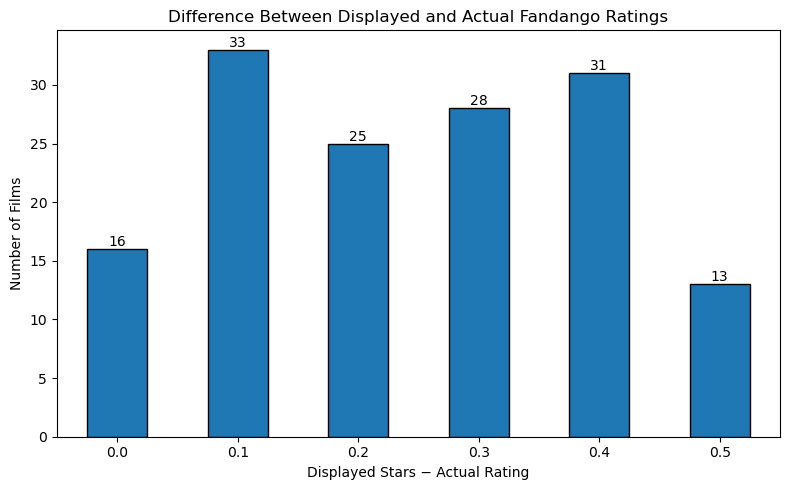

In [18]:
#Visuals
difference_counts = (
    fandango["Fandango_Difference"]
    .value_counts()
    .sort_index()
)

ax = difference_counts.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Difference Between Displayed and Actual Fandango Ratings")
plt.xlabel("Displayed Stars − Actual Rating")
plt.ylabel("Number of Films")
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The comparison between Fandango's displayed star ratings and the underlying numerical ratings shows a consistent positive difference. Most films had displayed ratings that exceeded the underlying rating by between 0.1 and 0.4 stars, with 0.1 stars being the most common difference. No films displayed a lower star rating than the underlying score, providing evidence that Fandango systematically rounded ratings upwards for presentation.

#### Step 3 Comparing Fandango's Ratings to Other Platforms and Step 4 visualise the distribution of ratings

In [22]:
ratings = fandango[
    [
        "Fandango_Ratingvalue",
        "RT_norm",
        "Metacritic_norm",
        "IMDB_norm"
    ]
]

ratings.describe().round(2)

,Fandango_Ratingvalue,RT_norm,Metacritic_norm,IMDB_norm
count,146.00,146.00,146.00,146.00
mean,3.85,3.04,2.94,3.37
std,0.50,1.51,0.98,0.48
min,2.70,0.25,0.65,2.00
25%,3.50,1.56,2.17,3.15
50%,3.90,3.18,2.95,3.45
75%,4.20,4.45,3.75,3.70
max,4.80,5.00,4.70,4.30


In [23]:
average_ratings = ratings.mean().sort_values(ascending=False)

print(average_ratings)

Fandango_Ratingvalue    3.845205
IMDB_norm               3.368493
RT_norm                 3.042466
Metacritic_norm         2.940411
dtype: float64


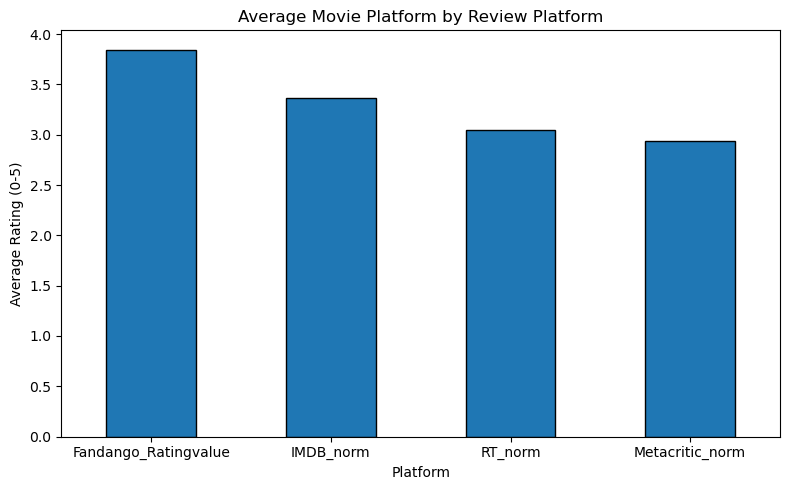

In [24]:
#Visualising average ratings
average_ratings.plot(
    kind='bar',
    figsize=(8,5),
    edgecolor='black'
    )
plt.title("Average Movie Platform by Review Platform")
plt.xlabel("Platform")
plt.ylabel("Average Rating (0-5)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

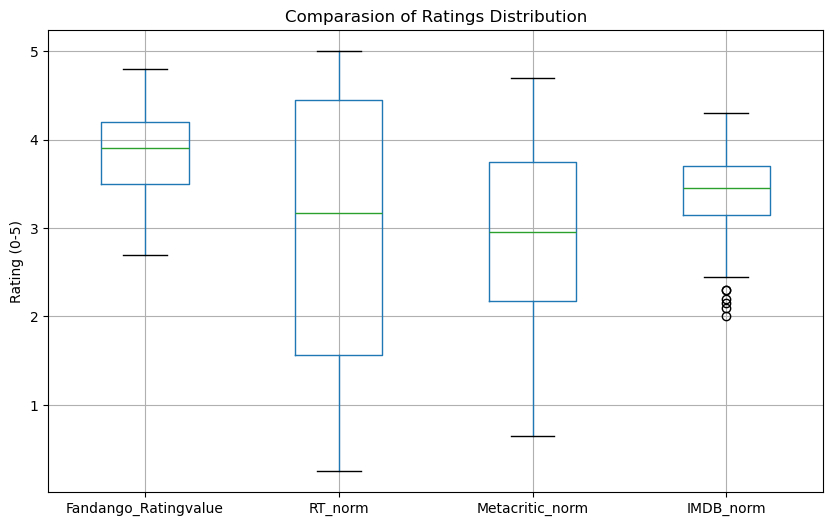

In [25]:
#Rating Distributions
ratings.boxplot(figsize=(10,6))
plt.title("Comparasion of Ratings Distribution")
plt.ylabel("Rating (0-5)")
plt.show()

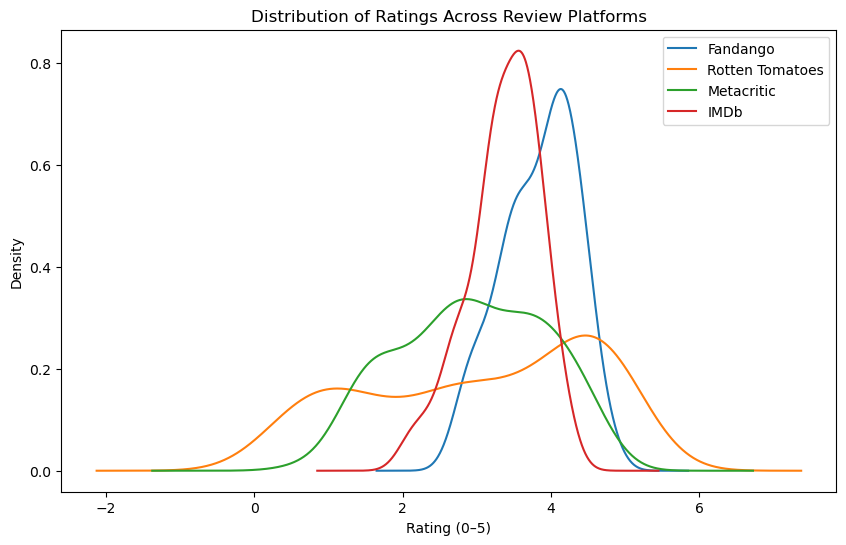

In [ ]:
#Density plot
plt.figure(figsize=(10,6))

ratings["Fandango_Ratingvalue"].plot(
    kind="density",
    label="Fandango"
)


ratings["RT_norm"].plot(
    kind="density",
    label="Rotten Tomatoes"
)

ratings["Metacritic_norm"].plot(
    kind="density",
    label="Metacritic"
)

ratings["IMDB_norm"].plot(
    kind="density",
    label="IMDb"
)

plt.title("Distribution of Ratings Across Review Platforms")
plt.xlabel("Rating (0–5)")
plt.legend()

plt.show()

##### Average Ratings

The bar chart shows that Fandango awarded the highest average movie rating (3.85/5) among all four review platforms. IMDb recorded the second-highest average rating (3.37/5), while Rotten Tomatoes (3.04/5) and Metacritic (2.94/5) were noticeably more conservative. The difference of almost 0.9 stars between Fandango and Metacritic suggests a substantial divergence in how films were evaluated.

##### Distribution Comparison

The box plot demonstrates that Fandango ratings were concentrated within a relatively narrow range of higher scores, with a median close to 4 stars. In contrast, Rotten Tomatoes and Metacritic exhibited much wider distributions, reflecting greater variation in film quality and more lower-rated titles. IMDb occupied a middle position, with a moderate spread and several lower-rating outliers.

##### Density Comparison

The density plot further reinforces these findings. Fandango's ratings are shifted noticeably to the right compared with the other platforms, indicating a consistent tendency toward higher ratings. Rotten Tomatoes and Metacritic display broader distributions across the rating scale, while IMDb's distribution falls between Fandango and the critic-based platforms.

##### Summary of this step

Across all three comparisons, Fandango consistently assigned higher ratings than IMDb, Rotten Tomatoes, and Metacritic. The higher average rating, concentration of scores near four stars, and right-shifted rating distribution all suggest that Fandango presented films more favourably than competing review platforms. These findings provide further evidence supporting the claim that Fandango's ratings were systematically inflated during the period analysed.

## Step 5 Conclusion

##### Conclusion

The analysis provides strong evidence supporting Walt Hickey's claim that Fandango's movie ratings were biased upwards during the period analysed.

Comparison of the displayed star ratings with the underlying numerical ratings showed that Fandango consistently presented ratings that were equal to or higher than the hidden rating values. No films displayed a lower star rating than the underlying score, and most films exhibited positive differences ranging from 0.1 to 0.4 stars, indicating systematic upward rounding.

Further comparison with competing review platforms demonstrated that Fandango awarded substantially higher ratings overall. The average Fandango rating (3.85/5) exceeded IMDb (3.37/5), Rotten Tomatoes (3.04/5), and Metacritic (2.94/5). The box plot and density plot also showed that Fandango's ratings were concentrated around higher values, whereas the other platforms displayed broader distributions and lower average scores.

Taken together, these findings indicate that Fandango presented films more favourably than competing review platforms during the 2015 period analysed. While the analysis cannot determine the intent behind these differences, the statistical evidence supports the conclusion that Fandango's displayed ratings exhibited a positive bias relative to both its underlying rating values and other major review platforms.